Finding the best site the bet on is a time-consuming and challenging task. With odds constantly changing, finding what place is giving you the best odds manually is nearly impossible. Initially, our objective was to create a web-scraping algorithm to scrape odds from different betting sites in order to obtain our information. We quickly realized that this process would be too difficult since 1. betting sites encrypt their data when you inspect their page to prevent web scraping and 2. if we were to manage to webscrape a betting site, many betting sites update their encryptions periodically which could prove to be another problem down the road. 

Instead, we found a sports betting API (the-odds-api) that compiles the moneyline and spread odds from multiple sports betting sites. Due to the limited number of games per day, we want to create a pipeline that cleans the data we retrieve as a json into a more readable nested dictionary/pandas dataframe. 

In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import json

#Source: https://the-odds-api.com/
url = f'https://api.the-odds-api.com/v4/sports/basketball_nba/odds/?apiKey=eaa265db381b34b1dbe2ce35e2628048&regions=us&markets=h2h,spreads,totals&oddsFormat=american'
betting_text = requests.get(url).text
betting_data = json.loads(betting_text)

In [2]:
len(betting_data)

10

In [3]:
sites_list = list()
for game in betting_data:
    bookmakers = game['bookmakers']
    for site in bookmakers:
        sites_list.append(site['title'])

In [4]:
sites_list = list(set(sites_list))

In [5]:
betting_data

[{'id': '4c5934f64a6a69c2ef0611de79d657ae',
  'sport_key': 'basketball_nba',
  'sport_title': 'NBA',
  'commence_time': '2022-04-01T23:10:00Z',
  'home_team': 'Washington Wizards',
  'away_team': 'Dallas Mavericks',
  'bookmakers': [{'key': 'fanduel',
    'title': 'FanDuel',
    'last_update': '2022-04-01T18:11:46Z',
    'markets': [{'key': 'h2h',
      'outcomes': [{'name': 'Dallas Mavericks', 'price': -360},
       {'name': 'Washington Wizards', 'price': 290}]},
     {'key': 'spreads',
      'outcomes': [{'name': 'Dallas Mavericks', 'price': -112, 'point': -8.0},
       {'name': 'Washington Wizards', 'price': -108, 'point': 8.0}]},
     {'key': 'totals',
      'outcomes': [{'name': 'Over', 'price': -110, 'point': 217.0},
       {'name': 'Under', 'price': -110, 'point': 217.0}]}]},
   {'key': 'wynnbet',
    'title': 'WynnBET',
    'last_update': '2022-04-01T18:11:47Z',
    'markets': [{'key': 'h2h',
      'outcomes': [{'name': 'Dallas Mavericks', 'price': -400},
       {'name': 'Washi

In [6]:
data_by_game = dict()



for game in betting_data:
    # Get the home team and away team by game and format it for easier viewing
    
    home = game['home_team']
    away = game['away_team']
    
    matchup = f'{away} @ {home}'
    
    # Keep the matchup name as the key, will store odds by site as value
    data_by_game[matchup] = dict()
    
    bookmakers = game['bookmakers']
    for site in bookmakers:
        site_title = site['title']
        data_by_game[matchup][site_title] = dict()
        markets = site['markets']
        
        for market in markets:
            bet_format = market['key']
            data_by_game[matchup][site_title][bet_format] = market['outcomes']
            
            

import pprint


pp = pprint.PrettyPrinter(indent=4)
pp.pprint(data_by_game)


{   'Dallas Mavericks @ Washington Wizards': {   'Barstool Sportsbook': {   'h2h': [   {   'name': 'Dallas '
                                                                                                   'Mavericks',
                                                                                           'price': -375},
                                                                                       {   'name': 'Washington '
                                                                                                   'Wizards',
                                                                                           'price': 290}],
                                                                            'spreads': [   {   'name': 'Dallas '
                                                                                                       'Mavericks',
                                                                                               'point': -8.5,
   

                                                          'h2h_lay': [   {   'name': 'Boston '
                                                                                     'Celtics',
                                                                             'price': -833},
                                                                         {   'name': 'Indiana '
                                                                                     'Pacers',
                                                                             'price': 1000}]},
                                           'Bovada': {   'h2h': [   {   'name': 'Boston '
                                                                                'Celtics',
                                                                        'price': -1500},
                                                                    {   'name': 'Indiana '
                                                                     

                                                   'PointsBet (US)': {   'h2h': [   {   'name': 'Denver '
                                                                                                'Nuggets',
                                                                                        'price': -145},
                                                                                    {   'name': 'Minnesota '
                                                                                                'Timberwolves',
                                                                                        'price': 125}],
                                                                         'spreads': [   {   'name': 'Denver '
                                                                                                    'Nuggets',
                                                                                            'point': -2.5,
                              

                                                                                            {   'name': 'San '
                                                                                                        'Antonio '
                                                                                                        'Spurs',
                                                                                                'price': -1667}],
                                                                                 'spreads': [   {   'name': 'Portland '
                                                                                                            'Trail '
                                                                                                            'Blazers',
                                                                                                    'point': 15.0,
                                                                            

                                                                    {   'name': 'Toronto '
                                                                                'Raptors',
                                                                        'price': -635}],
                                                         'spreads': [   {   'name': 'Orlando '
                                                                                    'Magic',
                                                                            'point': 11.5,
                                                                            'price': -105},
                                                                        {   'name': 'Toronto '
                                                                                    'Raptors',
                                                                            'point': -11.5,
                                                                            

In [7]:
df_bets = pd.DataFrame()

for game in betting_data:
    # Get the home team and away team by game and format it for easier viewing
    
    team_home = game['home_team']
    team_away = game['away_team']
    Game_ID = game['id']
    
    bookmakers = game['bookmakers']
    
    for site in bookmakers:
        site_title = site['title']
        #data_by_game[matchup][site_title] = dict()
        markets = site['markets']
        
             
        for market in markets:
            bet_format = market['key']
            bet = market['outcomes']
            
            bet_dict = {}
            bet_dict['Game_ID'] = Game_ID
            bet_dict['bet_format'] = market['key']
            bet_dict['site_title'] = site_title
            bet_dict['home_team'] = team_home
            bet_dict['away_team'] = team_away
            
            bet_dict['name_home'] = bet[0]['name']
            bet_dict['price_home'] = bet[0]['price']
            bet_dict['name_away'] = bet[1]['name']
            bet_dict['price_away'] = bet[1]['price']
            
            df_bets = df_bets.append(bet_dict, ignore_index = True)
     

    

df_bets_grouped = df_bets.groupby('Game_ID')

Text(0.5, 1.0, 'Washington Wizards @ Dallas Mavericks ')

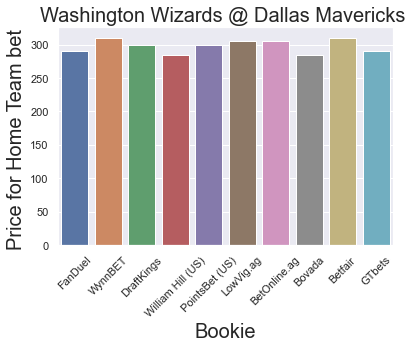

In [17]:
h2h = df_bets['bet_format'] == 'h2h'
df_bets_h2h = df_bets.loc[h2h, :]

df_bets_h2h = df_bets_h2h.set_index('Game_ID')

game_1 = df_bets_h2h.loc[df_bets_h2h.index[0]]

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
chart = sns.barplot(x="site_title",y = "price_away",data= game_1.iloc[:10])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45)
chart.set_xlabel("Bookie", fontsize = 20)
chart.set_ylabel("Price for Home Team bet ", fontsize = 20)

home_team_Str = game_1['home_team'][0]
away_team_Str = game_1['away_team'][0]

chart.set_title(f'{home_team_Str} @ {away_team_Str} ', fontsize = 20)

Text(0.5, 1.0, 'H:Boston Celtics vs A:Indiana Pacers ')

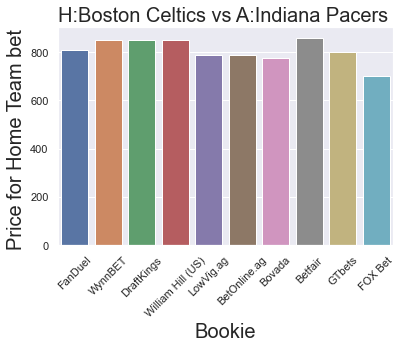

In [31]:
game_2 = df_bets_h2h.loc[df_bets_h2h.index[44]]

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
chart = sns.barplot(x="site_title",y = "price_away",data= game_2.iloc[:10])
chart.set_xticklabels(chart.get_xticklabels(), rotation=45)
chart.set_xlabel("Bookie", fontsize = 20)
chart.set_ylabel("Price for Home Team bet ", fontsize = 20)

home_team_Str = game_2['home_team'][0]
away_team_Str = game_2['away_team'][0]

chart.set_title(f'H:{home_team_Str} vs A:{away_team_Str} ', fontsize = 20)

In [84]:
df_bets_ = df_bets.set_index('Game_ID','site_title')

h2h = df_bets_['bet_format'] == 'h2h'
df_bets_h2h = df_bets_.loc[h2h, :]

max_game = df_bets_h2h.groupby(level=0).min('price_away')
max_game


,price_away,price_home
Game_ID,,
471a9aed408a694e07761e968d7b6b4a,-350.0,230.0
4c5934f64a6a69c2ef0611de79d657ae,285.0,-455.0
6233ad7c2ab45b7c40405bd0e262b6d1,-135.0,-105.0
7aa64230a9d762474b6cd15e0fb6d4e1,114.0,-150.0
7d90e68a239c8646006d7620b8228887,700.0,-2500.0
8a9374e8e07098e2f1ec61ba67fba3f8,-909.0,425.0
8cc897b46363c5b3868b4a12ed8e069e,-149.0,115.0
a265c7ac67fdc509e0952651cd8fc1fb,155.0,-213.0
b23bb1cf0c7f8f6172ce0247829a1a6e,-180.0,125.0


In [87]:
df_bets_ = df_bets.set_index(['Game_ID', 'site_title'])

h2h = df_bets_['bet_format'] == 'h2h'
df_bets_h2h = df_bets_.loc[h2h, :]


game__ = df_bets_.groupby('Game_ID')('price_away','site_title').max()
bet_count = game__.reset_index()
from collections import Counter
#print(Counter(bet_count['']))
bet_count



TypeError: 'DataFrameGroupBy' object is not callable

In [68]:
df_bets_h2h.head(10)

for index_0 in df_bets_h2h.index.levels[0]:
    game_ = df_bets_h2h.loc[df_bets_h2h.index[index_0]]
    h2h = df_bets['bet_format'] == 'h2h'
    df_bets_h2h = df_bets.loc[h2h, :]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [77]:
df_bets_ = df_bets.set_index(['Game_ID', 'site_title'])

max_game = df_bets_.groupby(level=0).apply(max)

game__ = df_bets_.groupby('site_title')['price_away'].max()
max_game

,away_team,bet_format,home_team,name_away,name_home,price_away,price_home
Game_ID,,,,,,,
471a9aed408a694e07761e968d7b6b4a,Phoenix Suns,totals,Memphis Grizzlies,Under,Over,-102.0,275.0
4c5934f64a6a69c2ef0611de79d657ae,Dallas Mavericks,totals,Washington Wizards,Washington Wizards,Over,320.0,-105.0
6233ad7c2ab45b7c40405bd0e262b6d1,New Orleans Pelicans,totals,Los Angeles Lakers,Under,Over,-105.0,114.0
7aa64230a9d762474b6cd15e0fb6d4e1,Minnesota Timberwolves,totals,Denver Nuggets,Under,Over,130.0,-103.0
7d90e68a239c8646006d7620b8228887,Indiana Pacers,totals,Boston Celtics,Under,Over,1100.0,100.0
8a9374e8e07098e2f1ec61ba67fba3f8,Toronto Raptors,totals,Orlando Magic,Under,Over,-105.0,560.0
8cc897b46363c5b3868b4a12ed8e069e,Sacramento Kings,totals,Houston Rockets,Under,Over,-105.0,134.0
a265c7ac67fdc509e0952651cd8fc1fb,Detroit Pistons,totals,Oklahoma City Thunder,Under,Over,188.0,-105.0
b23bb1cf0c7f8f6172ce0247829a1a6e,Los Angeles Clippers,totals,Milwaukee Bucks,Under,Over,-101.0,154.0
